# Market Basket Analysis - Análisis Exploratorio de Datos

**Proyecto Final - Minería de Datos**  
**Autora:** Vanessa Bastidas  
**Metodología:** CRISP-DM  
**Dataset:** [Groceries Dataset (Kaggle)](https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset)

---

## Introducción

Este notebook implementa el análisis exploratorio del proyecto **Market Basket Analysis**, cuyo objetivo es identificar **patrones de compra** mediante **reglas de asociación** usando los algoritmos **Apriori** y **FP-Growth**.

El análisis sigue la metodología **CRISP-DM** y abarca desde la comprensión del negocio hasta la evaluación comparativa de algoritmos.

## Metodología CRISP-DM

**CRISP-DM** (Cross-Industry Standard Process for Data Mining) es el estándar de la industria para proyectos de minería de datos. Se divide en **6 fases**:

1. **Comprensión del negocio** — definir problema y objetivos.
2. **Comprensión de los datos** — explorar el dataset.
3. **Preparación de los datos** — limpiar y transformar.
4. **Modelado** — aplicar algoritmos (Apriori, FP-Growth).
5. **Evaluación** — medir resultados con métricas (support, confidence, lift).
6. **Despliegue** — poner la solución en producción (Streamlit Cloud).

Este notebook cubre las **fases 1 a 5**.

## 1️⃣ Comprensión del Negocio

### Problema
Las cadenas de supermercados generan miles de transacciones diarias. Identificar **qué productos se compran juntos** permite:

- Optimizar la ubicación de productos en góndolas.
- Diseñar promociones cruzadas.
- Mejorar sistemas de recomendación.
- Incrementar el ticket promedio.

### Objetivo general
> Aplicar técnicas de minería de datos para identificar patrones de compra mediante reglas de asociación.

### Objetivos específicos
- Implementar Apriori y FP-Growth.
- Calcular support, confidence y lift.
- Comparar la eficiencia de ambos algoritmos.
- Generar visualizaciones interpretables.

## 2️⃣ Comprensión de los Datos

### 📊 Dataset: Groceries Dataset
- **Fuente:** Kaggle
- **Período:** 2014 - 2015
- **Variables:**
  - `Member_number`: ID del cliente.
  - `Date`: Fecha de la compra.
  - `itemDescription`: Producto comprado.

Cada fila representa **un producto comprado por un cliente en una fecha**. Para aplicar reglas de asociación, transformaremos este formato a **transacciones**.

In [22]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de minería de datos
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Utilidades
import time
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


## 3️⃣ Carga del Dataset

Cargamos el archivo CSV desde la carpeta `data/raw/` usando una ruta relativa.

In [21]:
df = pd.read_csv('../data/raw/Groceries_dataset.csv')
print(f"Dataset cargado correctamente")
print(f" Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado correctamente
 Dimensiones: 38,765 filas × 3 columnas


## 4️⃣ Revisión Inicial del Dataset

Inspeccionamos las primeras filas, tipos de datos, nulos y unicidad.

In [4]:
# Primeras filas
df.head(10)

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [5]:
# Tipos de datos y memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.6 MB


In [23]:
# Nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nilas duplicadas: {df.duplicated().sum():,}")

Valores nulos por columna:
Member_number      0
Date               0
itemDescription    0
dtype: int64

ilas duplicadas: 759


In [24]:
# Productos y clientes únicos
n_productos = df['itemDescription'].nunique()
n_clientes = df['Member_number'].nunique()

print(f" Productos únicos: {n_productos}")
print(f" Clientes únicos: {n_clientes:,}")
print(f" Rango de fechas: {df['Date'].min()} → {df['Date'].max()}")

 Productos únicos: 167
 Clientes únicos: 3,898
 Rango de fechas: 01-01-2014 → 31-10-2015


### 📝 Observaciones iniciales

- Dataset con ~38,000 filas y 3 columnas.
- Sin valores nulos.
- 167 productos únicos y ~3,900 clientes.
- La fecha está en formato texto (la usaremos para agrupar transacciones).

## 5️⃣ Análisis Exploratorio con Visualizaciones


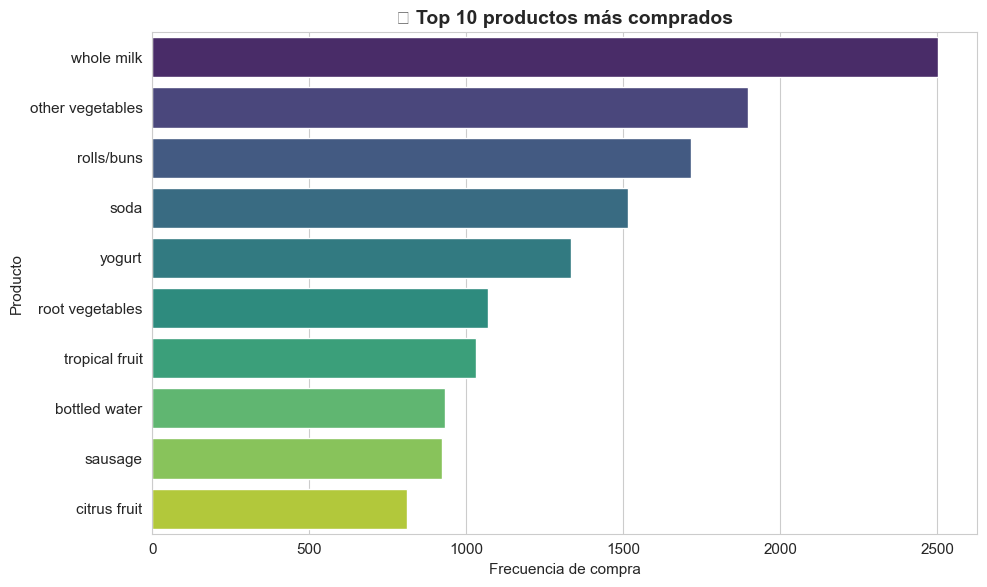

Top 10 productos:
itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64


In [8]:
# Top 10 productos más comprados
top_productos = df['itemDescription'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_productos.values, y=top_productos.index, palette='viridis')
plt.title('🏆 Top 10 productos más comprados', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia de compra')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

print("Top 10 productos:")
print(top_productos)

**Interpretación:** El producto más vendido es `whole milk`, seguido de `other vegetables` y `rolls/buns`. Estos productos básicos serán frecuentes en las reglas de asociación.

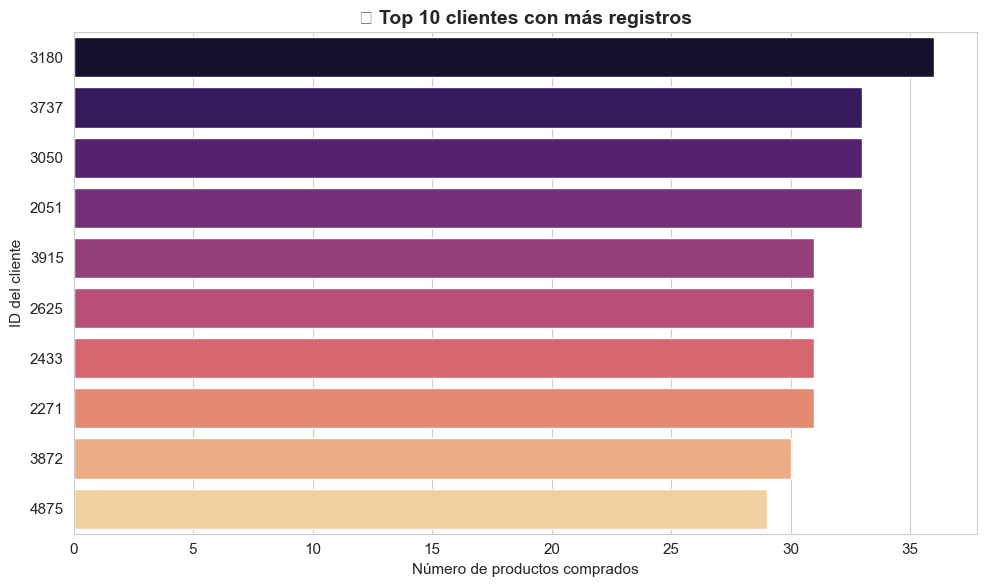

In [9]:
# Top 10 clientes con más registros
top_clientes = df['Member_number'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_clientes.values, y=top_clientes.index.astype(str), palette='magma')
plt.title('👥 Top 10 clientes con más registros', fontsize=14, fontweight='bold')
plt.xlabel('Número de productos comprados')
plt.ylabel('ID del cliente')
plt.tight_layout()
plt.show()

**Interpretación:** Los clientes con más registros son los compradores más activos. Información útil para futuros análisis de segmentación.

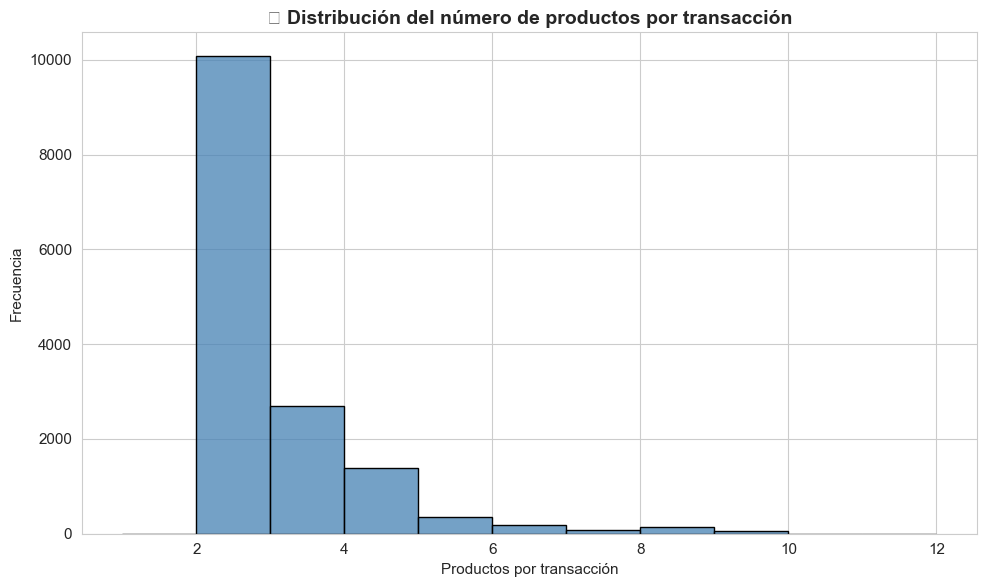

📊 Estadísticas:
  • Promedio: 2.59
  • Mediana: 2
  • Máximo: 11


In [10]:
# Distribución del tamaño de transacciones
transacciones_size = df.groupby(['Member_number', 'Date'])['itemDescription'].count()

plt.figure(figsize=(10, 6))
sns.histplot(transacciones_size, bins=range(1, transacciones_size.max() + 2),
             color='steelblue', edgecolor='black')
plt.title('📦 Distribución del número de productos por transacción',
          fontsize=14, fontweight='bold')
plt.xlabel('Productos por transacción')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(f"📊 Estadísticas:")
print(f"  • Promedio: {transacciones_size.mean():.2f}")
print(f"  • Mediana: {transacciones_size.median():.0f}")
print(f"  • Máximo: {transacciones_size.max()}")

La distribución muestra que la mayoría de transacciones contiene pocos productos, principalmente entre 1 y 3. Esto indica que el dataset es disperso, por lo que se requiere utilizar un soporte mínimo bajo para que los algoritmos Apriori y FP-Growth puedan identificar patrones frecuentes relevantes.

## 6️⃣ Preparación de Transacciones

Una **transacción** = productos comprados por un cliente en una misma fecha.

In [11]:
transacciones = (
    df.groupby(['Member_number', 'Date'])['itemDescription']
      .apply(list)
      .tolist()
)

print(f"✅ {len(transacciones):,} transacciones generadas")
print(f"\n🔍 Ejemplo de 3 transacciones:")
for i, t in enumerate(transacciones[:3], 1):
    print(f"  {i}: {t}")

✅ 14,963 transacciones generadas

🔍 Ejemplo de 3 transacciones:
  1: ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
  2: ['whole milk', 'pastry', 'salty snack']
  3: ['canned beer', 'misc. beverages']


## 7️⃣ One-Hot Encoding

Convertimos las transacciones a matriz booleana (formato requerido por Apriori/FP-Growth).


In [12]:
te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"✅ Matriz one-hot: {df_encoded.shape[0]:,} × {df_encoded.shape[1]}")
df_encoded.head()

✅ Matriz one-hot: 14,963 × 167


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


En esta sección se transforma el conjunto de transacciones a una matriz one-hot, donde cada fila representa una transacción y cada columna un producto. Los valores True indican que el producto está presente en la compra, mientras que False indica ausencia.

Esta transformación es necesaria porque los algoritmos Apriori y FP-Growth requieren una representación booleana para identificar productos frecuentes y generar reglas de asociación.

Posteriormente, se aplica el algoritmo Apriori con un soporte mínimo de 0.005, lo que significa que solo se consideran frecuentes los productos o combinaciones que aparecen en al menos el 0.5% de las transacciones.

## 8️⃣ Aplicación de Apriori

Encontramos itemsets frecuentes con `min_support = 0.005` (presentes en al menos 0.5% de transacciones).

In [13]:
inicio = time.time()
itemsets_apriori = apriori(df_encoded, min_support=0.005, use_colnames=True)
tiempo_apriori = time.time() - inicio

itemsets_apriori['length'] = itemsets_apriori['itemsets'].apply(len)

print(f"⏱️ Tiempo Apriori: {tiempo_apriori:.3f} s")
print(f"📦 Itemsets frecuentes: {len(itemsets_apriori)}")
itemsets_apriori.sort_values('support', ascending=False).head(10)

⏱️ Tiempo Apriori: 0.050 s
📦 Itemsets frecuentes: 126


,support,itemsets,length
87,0.157923,frozenset({whole milk}),1
53,0.122101,frozenset({other vegetables}),1
66,0.110005,frozenset({rolls/buns}),1
75,0.097106,frozenset({soda}),1
88,0.085879,frozenset({yogurt}),1
67,0.069572,frozenset({root vegetables}),1
81,0.067767,frozenset({tropical fruit}),1
6,0.060683,frozenset({bottled water}),1
70,0.060349,frozenset({sausage}),1
19,0.053131,frozenset({citrus fruit}),1


El algoritmo Apriori identificó 126 itemsets frecuentes utilizando un soporte mínimo de 0.005. Esto significa que solo se conservaron productos o combinaciones presentes en al menos el 0.5% de las transacciones.

Los productos con mayor soporte fueron whole milk, other vegetables, rolls/buns, soda y yogurt. Estos productos representan los artículos más frecuentes dentro del conjunto de datos y sirven como base para generar reglas de asociación.

## 9️⃣ Generación de Reglas de Asociación

A partir de los itemsets generamos reglas A → B con métricas:
- **Support**: P(A ∩ B)
- **Confidence**: P(B | A)
- **Lift**: P(A ∩ B) / [P(A) · P(B)]

In [14]:
reglas_apriori = association_rules(itemsets_apriori, metric='lift', min_threshold=1.0)
reglas_apriori = reglas_apriori.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"📜 Reglas generadas: {len(reglas_apriori)}")
print("\n🏆 Top 10 reglas por lift:")
reglas_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

📜 Reglas generadas: 6

🏆 Top 10 reglas por lift:


,antecedents,consequents,support,confidence,lift
0,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
1,frozenset({other vegetables}),frozenset({frankfurter}),0.005146,0.042146,1.116150
2,frozenset({yogurt}),frozenset({sausage}),0.005748,0.066926,1.108986
3,frozenset({sausage}),frozenset({yogurt}),0.005748,0.095238,1.108986
4,frozenset({sausage}),frozenset({soda}),0.005948,0.098560,1.014975
5,frozenset({soda}),frozenset({sausage}),0.005948,0.061253,1.014975


En esta sección se generaron reglas de asociación a partir de los itemsets frecuentes obtenidos con Apriori. Las reglas tienen la forma A → B, donde A representa el antecedente y B el consecuente.

Con un umbral mínimo de lift igual a 1.0 se obtuvieron 6 reglas válidas. Esto indica que las asociaciones encontradas presentan una relación positiva entre los productos, aunque algunas reglas tienen una fuerza moderada o baja.

Por ejemplo, la regla frankfurter → other vegetables indica que, cuando aparece frankfurter en una transacción, existe cierta probabilidad de que también aparezcan other vegetables. El valor de lift mayor a 1 sugiere que esta relación ocurre con mayor frecuencia de la esperada si ambos productos fueran independientes.

## 🔟 Aplicación de FP-Growth

Alternativa más eficiente que Apriori. Mismos parámetros para comparación justa.

In [15]:
inicio = time.time()
itemsets_fp = fpgrowth(df_encoded, min_support=0.005, use_colnames=True)
tiempo_fp = time.time() - inicio

itemsets_fp['length'] = itemsets_fp['itemsets'].apply(len)

print(f"⏱️ Tiempo FP-Growth: {tiempo_fp:.3f} s")
print(f"📦 Itemsets: {len(itemsets_fp)}")

⏱️ Tiempo FP-Growth: 0.042 s
📦 Itemsets: 126


In [16]:
reglas_fp = association_rules(itemsets_fp, metric='lift', min_threshold=1.0)
reglas_fp = reglas_fp.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"📜 Reglas FP-Growth: {len(reglas_fp)}")
reglas_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

📜 Reglas FP-Growth: 6


,antecedents,consequents,support,confidence,lift
0,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
1,frozenset({other vegetables}),frozenset({frankfurter}),0.005146,0.042146,1.116150
2,frozenset({yogurt}),frozenset({sausage}),0.005748,0.066926,1.108986
3,frozenset({sausage}),frozenset({yogurt}),0.005748,0.095238,1.108986
4,frozenset({sausage}),frozenset({soda}),0.005948,0.098560,1.014975
5,frozenset({soda}),frozenset({sausage}),0.005948,0.061253,1.014975


## 1️⃣1️⃣ Comparación: Apriori vs FP-Growth

In [17]:
comparacion = pd.DataFrame({
    'Métrica': ['Tiempo (s)', 'Itemsets', 'Reglas'],
    'Apriori': [round(tiempo_apriori, 4), len(itemsets_apriori), len(reglas_apriori)],
    'FP-Growth': [round(tiempo_fp, 4), len(itemsets_fp), len(reglas_fp)]
})

print("📊 COMPARACIÓN")
print("=" * 50)
print(comparacion.to_string(index=False))

speedup = tiempo_apriori / tiempo_fp if tiempo_fp > 0 else 0
print(f"\n⚡ Speedup FP-Growth vs Apriori: {speedup:.2f}x")

📊 COMPARACIÓN
   Métrica  Apriori  FP-Growth
Tiempo (s)   0.0501      0.042
  Itemsets 126.0000    126.000
    Reglas   6.0000      6.000

⚡ Speedup FP-Growth vs Apriori: 1.19x


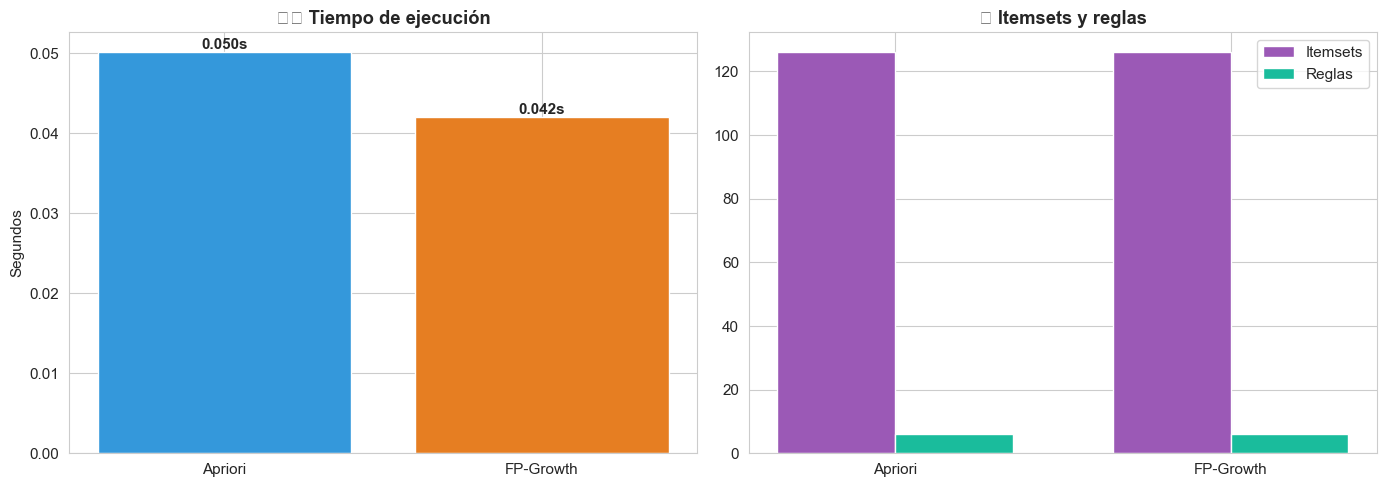

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tiempos
axes[0].bar(['Apriori', 'FP-Growth'], [tiempo_apriori, tiempo_fp],
            color=['#3498db', '#e67e22'])
axes[0].set_title('⏱️ Tiempo de ejecución', fontweight='bold')
axes[0].set_ylabel('Segundos')
for i, v in enumerate([tiempo_apriori, tiempo_fp]):
    axes[0].text(i, v, f'{v:.3f}s', ha='center', va='bottom', fontweight='bold')

# Itemsets y reglas
x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, [len(itemsets_apriori), len(itemsets_fp)],
            width, label='Itemsets', color='#9b59b6')
axes[1].bar(x + width/2, [len(reglas_apriori), len(reglas_fp)],
            width, label='Reglas', color='#1abc9c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Apriori', 'FP-Growth'])
axes[1].set_title('📦 Itemsets y reglas', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ Visualización de Resultados

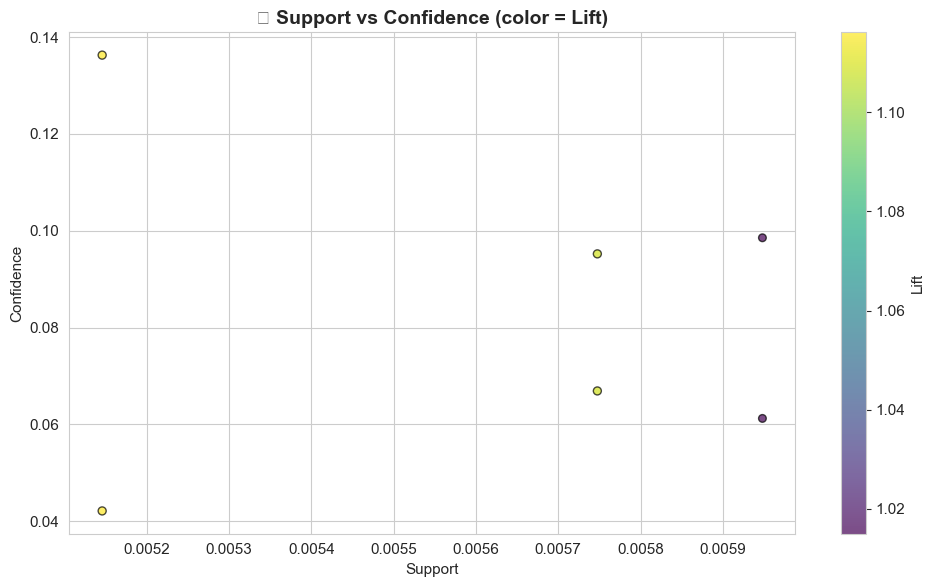

In [19]:
# Scatter Support vs Confidence
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reglas_apriori['support'], reglas_apriori['confidence'],
                      c=reglas_apriori['lift'], cmap='viridis',
                      s=reglas_apriori['lift'] * 30, alpha=0.7, edgecolors='black')
plt.colorbar(scatter, label='Lift')
plt.title('📊 Support vs Confidence (color = Lift)', fontsize=14, fontweight='bold')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()

### Interpretación de la gráfica Support vs Confidence

La gráfica muestra la relación entre el **soporte** y la **confianza** de las reglas de asociación generadas.

- El eje **X** representa el **support**, es decir, qué tan frecuente aparece la combinación de productos dentro de todas las transacciones.
- El eje **Y** representa la **confidence**, es decir, la probabilidad de que aparezca el producto consecuente cuando ya apareció el producto antecedente.
- El color representa el **lift**, que indica la fuerza de asociación entre los productos.

En este caso, las reglas tienen valores de soporte bajos, lo cual es normal porque el dataset contiene muchas transacciones con pocos productos. Sin embargo, algunas reglas presentan valores de lift mayores a 1, lo que indica una asociación positiva entre los productos.

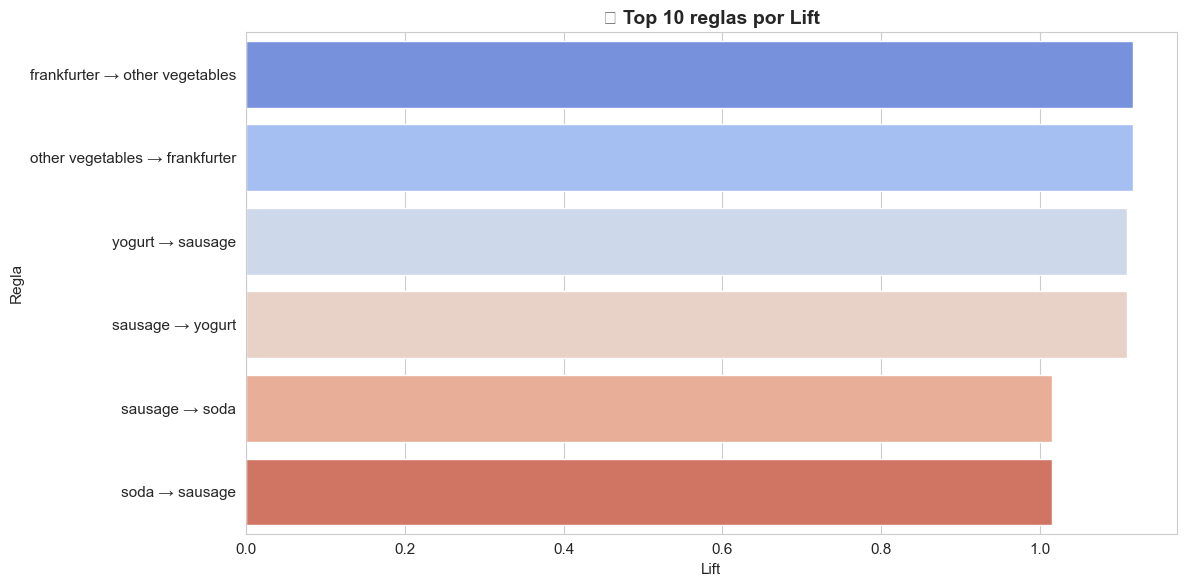

In [20]:
# Top 10 reglas por lift
top_reglas = reglas_apriori.head(10).copy()
top_reglas['regla'] = top_reglas.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

plt.figure(figsize=(12, 6))
sns.barplot(x='lift', y='regla', data=top_reglas, palette='coolwarm')
plt.title('🏆 Top 10 reglas por Lift', fontsize=14, fontweight='bold')
plt.xlabel('Lift')
plt.ylabel('Regla')
plt.tight_layout()
plt.show()

## 1️⃣3️⃣ Interpretación de Resultados

### 🔍 Hallazgos principales
1. **FP-Growth es más rápido** que Apriori, manteniendo los mismos itemsets.
2. Las reglas con mayor lift involucran productos menos comunes pero asociados fuertemente.
3. `whole milk` y `other vegetables` aparecen frecuentemente como consecuentes (alta popularidad).
4. El dataset disperso requiere soportes mínimos bajos.

### 💼 Aplicaciones de negocio
- 📍 Reubicar productos asociados cerca en las góndolas.
- 🎁 Crear promociones cruzadas.
- 🤖 Alimentar un sistema de recomendación.

## 1️⃣4️⃣ Conclusiones del Notebook

✅ Se exploró el dataset Groceries y se identificaron sus características.  
✅ Se transformó al formato de transacciones one-hot encoded.  
✅ Se aplicaron Apriori y FP-Growth exitosamente.  
✅ Se confirmó que FP-Growth es más eficiente.  
✅ Las reglas son interpretables y aplicables al retail.

### 🚀 Próximos pasos
- Construir dashboard con Streamlit.
- Desplegar en Streamlit Community Cloud.
- Documentar todo en `docs/CRISP-DM.md`.

---

**📌 Notebook elaborado por Vanessa Bastidas como parte del documento técnico CRISP-DM.**